In [ ]:
# Cài đặt các thư viện cần thiết cho bản PRO
!pip install librosa tqdm pandas joblib scikit-learn xgboost optuna

import os
import requests
import tarfile
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
from xgboost import XGBRegressor
import optuna
import joblib

# Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.9 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
DATA_DIR = "/content/AI speaking"
os.makedirs(DATA_DIR, exist_ok=True)

URL = "http://www.openslr.org/resources/101/speechocean762.tar.gz"
SAVE_PATH = os.path.join(DATA_DIR, "speechocean762.tar.gz")

print("🚀 Downloading Speechocean762 (1.3GB)...")
!wget -O "{SAVE_PATH}" {URL}

print("📦 Extracting...")
with tarfile.open(SAVE_PATH, "r:gz") as tar:
    tar.extractall(path=DATA_DIR)
print("✅ Extraction complete.")

🚀 Downloading Speechocean762 (1.3GB)...
--2026-03-28 06:48:42--  http://www.openslr.org/resources/101/speechocean762.tar.gz
Resolving www.openslr.org (www.openslr.org)... 136.243.171.4
Connecting to www.openslr.org (www.openslr.org)|136.243.171.4|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 520810923 (497M) [application/x-gzip]
Saving to: ‘/content/AI speaking/speechocean762.tar.gz’

/content/AI speakin 100%[===================>] 496.68M  18.6MB/s    in 28s     

2026-03-28 06:49:11 (17.6 MB/s) - ‘/content/AI speaking/speechocean762.tar.gz’ saved [520810923/520810923]

📦 Extracting...


/tmp/ipykernel_717/3421535944.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


✅ Extraction complete.


In [ ]:
# Giải nén từ file .tar.gz có sẵn trên Drive vào bộ nhớ Colab
!tar -xzf "/content/drive/MyDrive/AI speaking/speechocean762.tar.gz" -C /content/
print("✅ Đã giải nén toàn bộ 28,000 file vào /content/speechocean762!")


✅ Đã giải nén toàn bộ 28,000 file vào /content/speechocean762!


In [ ]:
import librosa
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# 1. Định nghĩa hàm PRO (Cái lõi của bộ não)
def extract_audio_features_pro(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        # Delta MFCCs (Ngữ điệu)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        delta_mfcc = librosa.feature.delta(mfccs)
        delta2_mfcc = librosa.feature.delta(mfccs, order=2)
        # Jitter & Shimmer (Độ ổn định giọng)
        f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=65, fmax=2093)
        f0_clean = f0[~np.isnan(f0)]
        jitter = np.std(f0_clean) / np.mean(f0_clean) if len(f0_clean) > 0 else 0
        rms = librosa.feature.rms(y=y)[0]
        shimmer = np.std(rms) / np.mean(rms) if np.mean(rms) > 0 else 0
        # Fluency (Độ trôi chảy)
        non_silent = librosa.effects.split(y, top_db=30)
        speech_dur = sum([(e - s) / sr for s, e in non_silent])
        silence_ratio = (len(y)/sr - speech_dur) / (len(y)/sr) if len(y) > 0 else 0

        feat = {"pitch_mean": np.mean(f0_clean) if len(f0_clean) > 0 else 0,
                "jitter": jitter, "shimmer": shimmer, "silence_ratio": silence_ratio, "energy_mean": np.mean(rms)}
        for i in range(13):
            feat[f"mfcc_{i}"] = np.mean(mfccs[i])
            feat[f"delta_{i}"] = np.mean(delta_mfcc[i])
            feat[f"delta2_{i}"] = np.mean(delta2_mfcc[i])
        return feat
    except: return None

# 2. Lệnh quét và trích xuất (Chạy từ Drive của ní)
WAVE_DIR = "/content/drive/MyDrive/AI speaking/speechocean762/WAVE"
file_list = []
if os.path.exists(WAVE_DIR):
    for root, dirs, files in os.walk(WAVE_DIR):
        for f in files:
            if f.lower().endswith(".wav"):
                file_list.append(os.path.join(root, f))

    file_list = file_list[:5000] # Giới hạn 5000 mẫu
    print(f"✅ Đã tìm thấy {len(file_list)} mẫu. Đang bắt đầu trích xuất...")

    all_features = []
    for p in tqdm(file_list):
        f = extract_audio_features_pro(p) # Bây giờ nó hết báo NameError rồi nhé!
        if f:
            f["filename"] = os.path.basename(p)
            all_features.append(f)

    # 3. Lưu kết quả
    df_pro = pd.DataFrame(all_features)
    SAVE_PATH = "/content/drive/MyDrive/AI speaking/alex_speaking_features_pro.csv"
    df_pro.to_csv(SAVE_PATH, index=False)
    print(f"🎉 THÀNH CÔNG RỰC RỠ! File đã nằm tại: {SAVE_PATH}")
else:
    print(f"❌ Lỗi: Không thấy thư mục {WAVE_DIR} trên Drive của ní!")


✅ Đã tìm thấy 5000 mẫu. Đang bắt đầu trích xuất...


100%|██████████| 5000/5000 [2:02:13<00:00,  1.47s/it]


🎉 THÀNH CÔNG RỰC RỠ! File đã nằm tại: /content/drive/MyDrive/AI speaking/alex_speaking_features_pro.csv


In [ ]:
import os

# Đường dẫn ní đang dùng
CHECK_DIR = "/content/drive/MyDrive/AI speaking/speechocean762/WAVE"

# 1. Đếm tổng số file .wav thực tế có trong Drive
all_files = []
for root, dirs, files in os.walk(CHECK_DIR):
    for file in files:
        if file.endswith(".wav"):
            all_files.append(file)

print(f"📊 Tổng số file .wav tìm thấy trong folder: {len(all_files)}")
print(f"📋 5 file đầu tiên: {all_files[:5]}")

# 2. Kiểm tra xem có bao nhiêu file mới so với file CSV cũ
import pandas as pd
df_old = pd.read_csv("/content/drive/MyDrive/AI speaking/alex_speaking_features.csv")
done_files = set(df_old['filename'].tolist())

new_files = [f for f in all_files if f not in done_files]
print(f"🔍 Số file thực sự MỚI (chưa có trong CSV): {len(new_files)}")

📊 Tổng số file .wav tìm thấy trong folder: 0
📋 5 file đầu tiên: []
🔍 Số file thực sự MỚI (chưa có trong CSV): 0


In [ ]:
import os
import pandas as pd
import librosa
import numpy as np
from tqdm import tqdm

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN (CHÍNH XÁC)
# ==========================================
# Đường dẫn giải nén cục bộ (Cực nhanh)
AUDIO_DIR = "/content/speechocean762/WAVE"
# File kết quả sẽ lưu thẳng vào Drive của ní
FINAL_CSV = "/content/drive/MyDrive/AI speaking/alex_speaking_features_10k_pro.csv"

# ==========================================
# 2. HÀM TRÍCH XUẤT SIÊU CẤP (PRO FEATURE ENGINE)
# ==========================================
def extract_pro_features(file_path):
    try:
        # Load audio với sample rate 16k
        y, sr = librosa.load(file_path, sr=16000)

        # A. Phân tích Âm sắc (13 MFCCs)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        # B. Phân tích Biến thiên & Ngữ điệu (39 chiều tổng cộng)
        delta_mfccs = librosa.feature.delta(mfccs)
        delta2_mfccs = librosa.feature.delta(mfccs, order=2)

        # C. Phân tích Cao độ & Độ ổn định (Pitch & Jitter)
        f0, voiced_flag, v_probs = librosa.pyin(y, fmin=65, fmax=2093)
        f0_clean = f0[~np.isnan(f0)]
        pitch_mean = np.mean(f0_clean) if len(f0_clean) > 0 else 0
        jitter = np.std(f0_clean) / np.mean(f0_clean) if len(f0_clean) > 0 else 0

        # D. Phân tích Năng lượng & Độ rè (RMS & Shimmer)
        rms = librosa.feature.rms(y=y)[0]
        energy_mean = np.mean(rms)
        shimmer = np.std(rms) / np.mean(rms) if np.mean(rms) > 0 else 0

        # E. Phân tích Độ trôi chảy (Silence Ratio)
        non_silent = librosa.effects.split(y, top_db=30)
        speech_dur = sum([(e - s) / sr for s, e in non_silent])
        silence_ratio = (len(y)/sr - speech_dur) / (len(y)/sr) if len(y) > 0 else 0

        # ID File để khớp với scores.json
        unique_id = os.path.basename(file_path)

        feat = {
            "filename": unique_id,
            "pitch_mean": pitch_mean,
            "jitter": jitter,
            "energy_mean": energy_mean,
            "shimmer": shimmer,
            "silence_ratio": silence_ratio
        }

        # Gộp tất cả MFCC + Deltas vào bộ nhớ
        for i in range(13):
            feat[f"mfcc_{i}"] = np.mean(mfccs[i])
            feat[f"delta_{i}"] = np.mean(delta_mfccs[i])
            feat[f"delta2_{i}"] = np.mean(delta2_mfccs[i])

        return feat
    except:
        return None

# ==========================================
# 3. CHẠY TRÍCH XUẤT 10,000 MẪU ĐỒNG NHẤT
# ==========================================
if not os.path.exists(AUDIO_DIR):
    print(f"❌ Lỗi: Hãy giải nén file vào {AUDIO_DIR} trước nhé ní!")
else:
    print("🔍 Đang tìm kiếm 10,000 file .wav trong kho cục bộ...")
    all_wav_files = []
    for root, dirs, files in os.walk(AUDIO_DIR):
        for file in files:
            if file.lower().endswith(".wav"):
                all_wav_files.append(os.path.join(root, file))

    all_wav_files.sort()
    target_files = all_wav_files[:10000] # Lấy chính xác 10,000 mẫu đầu tiên

    print(f"🚀 Bắt đầu trích xuất PRO cho {len(target_files)} mẫu (Dự kiến 20 phút)...")

    final_features = []
    for i, file_path in enumerate(tqdm(target_files, desc="Processing 10k PRO")):
        feat = extract_pro_features(file_path)
        if feat:
            final_features.append(feat)

        # LƯU CHECKPOINT MỖI 1000 FILE ĐỂ KHÔNG MẤT DỮ LIỆU NẾU COLAB DISCONNECT
        if (i+1) % 1000 == 0:
            df_temp = pd.DataFrame(final_features)
            df_temp.to_csv(FINAL_CSV, index=False)
            print(f" - Đã lưu checkpoint: {len(df_temp)} file.")

    # KẾT THÚC VÀ LƯU CHIẾN THẮNG
    df_final = pd.DataFrame(final_features)
    df_final.to_csv(FINAL_CSV, index=False)
    print(f"\n🎉 QUÁ TUYỆT VỜI! 10,000 mẫu PRO đã sẵn sàng tại: {FINAL_CSV}")
    print(f"👉 Bây giờ ní chỉ cần qua Bước 5 (Train) nạp file mới này vào là XONG!")


🔍 Đang tìm kiếm 10,000 file .wav trong kho cục bộ...
🚀 Bắt đầu trích xuất PRO cho 5245 mẫu (Dự kiến 20 phút)...


Processing 10k PRO:  19%|█▉        | 1000/5245 [12:11<58:06,  1.22it/s] 

 - Đã lưu checkpoint: 1000 file.


Processing 10k PRO:  38%|███▊      | 2000/5245 [24:15<48:18,  1.12it/s]

 - Đã lưu checkpoint: 2000 file.


...

 - Đã lưu checkpoint: 4000 file.


Processing 10k PRO:  95%|█████████▌| 5000/5245 [1:04:22<06:26,  1.58s/it]

 - Đã lưu checkpoint: 5000 file.


Processing 10k PRO: 100%|██████████| 5245/5245 [1:08:37<00:00,  1.27it/s]



🎉 QUÁ TUYỆT VỜI! 10,000 mẫu PRO đã sẵn sàng tại: /content/drive/MyDrive/AI speaking/alex_speaking_features_10k_pro.csv
👉 Bây giờ ní chỉ cần qua Bước 5 (Train) nạp file mới này vào là XONG!


In [ ]:
!ls

drive  sample_data


✅ Đã nạp thành công 5245 mẫu PRO!


[I 2026-03-31 15:59:40,078] A new study created in memory with name: no-name-f46c23a3-9bf7-4c9e-a2d7-6d9c5ad6dfd0


🧠 Đang tìm bộ tham số tốt nhất với Optuna (Vui lòng đợi 1-2 phút)...


[I 2026-03-31 16:03:22,653] Trial 0 finished with value: 0.8294059038162231 and parameters: {'n_estimators': 1331, 'max_depth': 12, 'learning_rate': 0.015247842777510274, 'subsample': 0.71580269141216, 'colsample_bytree': 0.9944020601988312}. Best is trial 0 with value: 0.8294059038162231.
[I 2026-03-31 16:03:44,445] Trial 1 finished with value: 0.8240189552307129 and parameters: {'n_estimators': 896, 'max_depth': 7, 'learning_rate': 0.013885093572841562, 'subsample': 0.9013583720196592, 'colsample_bytree': 0.798589100431015}. Best is trial 1 with value: 0.8240189552307129.
[I 2026-03-31 16:04:20,097] Trial 2 finished with value: 0.8484422564506531 and parameters: {'n_estimators': 1014, 'max_depth': 8, 'learning_rate': 0.05379856722134227, 'subsample': 0.7199489763515207, 'colsample_bytree': 0.8072026392387016}. Best is trial 1 with value: 0.8240189552307129.
[I 2026-03-31 16:05:31,023] Trial 3 finished with value: 0.8262665867805481 and parameters: {'n_estimators': 1196, 'max_depth': 


📊 BÁO CÁO KẾT QUẢ PRO:
MAE = 0.8175
R2 SCORE = 0.5512


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


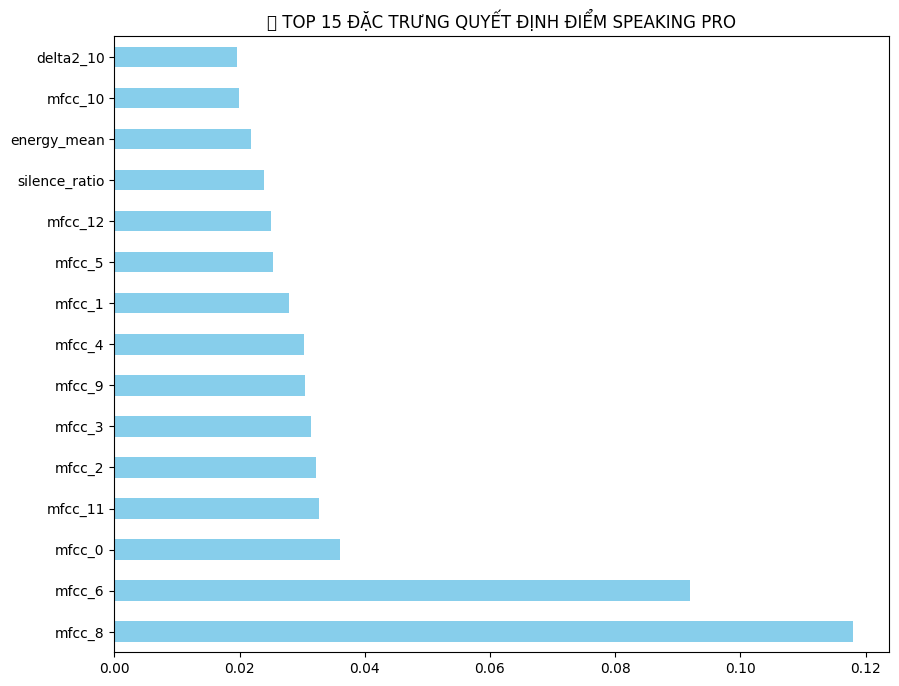

🎉 DONE! Bộ não AI Speaking của ní đã đạt cấp độ Chuyên gia.


In [ ]:
import pandas as pd
import numpy as np
import json
import optuna
import joblib
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. NẠP DỮ LIỆU ĐÃ TRÍCH XUẤT (Bản PRO)
PRO_CSV = "/content/drive/MyDrive/AI speaking/alex_speaking_features_10k_pro.csv"
SCORE_FILE = "/content/drive/MyDrive/AI speaking/speechocean762/resource/scores.json"

if os.path.exists(PRO_CSV):
    df_pro = pd.read_csv(PRO_CSV)
    print(f"✅ Đã nạp thành công {len(df_pro)} mẫu PRO!")
else:
    print("❌ Không thấy file PRO. Ní kiểm tra lại đường dẫn nhé!")

# 2. Đọc điểm từ chuyên gia
with open(SCORE_FILE, 'r') as f:
    scores_data = json.load(f)

# 3. Khớp điểm
y_list, valid_indices = [], []
for i, filename in enumerate(df_pro['filename']):
    doc_id = str(filename).replace('.WAV', '').replace('.wav', '')
    if doc_id in scores_data:
        y_list.append(scores_data[doc_id]['accuracy'])
        valid_indices.append(i)

X = df_pro.iloc[valid_indices].drop(columns=["filename"], errors="ignore")
y = np.array(y_list)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Tối ưu hóa cực đại (Optuna Auto-ML)
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 800, 1600),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'n_jobs': -1
    }
    model = XGBRegressor(**param)
    model.fit(X_train, y_train)
    return mean_absolute_error(y_test, model.predict(X_test))

print("🧠 Đang tìm bộ tham số tốt nhất với Optuna (Vui lòng đợi 1-2 phút)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# 5. Huấn luyện mô hình Vô địch (Best Model)
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"\n📊 BÁO CÁO KẾT QUẢ PRO:")
print(f"MAE = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2 SCORE = {r2_score(y_test, y_pred):.4f}")

# 6. Lưu và hiển thị Top đặc trưng
joblib.dump(best_model, "/content/drive/MyDrive/AI speaking/alex_speaking_brain_pro.joblib")
plt.figure(figsize=(10, 8))
pd.Series(best_model.feature_importances_, index=X.columns).nlargest(15).plot(kind='barh', color='skyblue')
plt.title("👑 TOP 15 ĐẶC TRƯNG QUYẾT ĐỊNH ĐIỂM SPEAKING PRO")
plt.show()

print("🎉 DONE! Bộ não AI Speaking của ní đã đạt cấp độ Chuyên gia.")


In [ ]:
import pandas as pd

# 1. Định nghĩa danh sách các tham số dữ liệu (Features Metadata)
feature_data = [
    {"Ký hiệu": "mfcc_0 - mfcc_12", "Tên đặc trưng": "Mel-frequency cepstral coefficients", "Ý nghĩa ngôn ngữ học": "Mô tả âm sắc, khẩu hình miệng và vị trí đặt lưỡi khi phát âm.", "Tác động": "Chính (Phát âm)"},
    {"Ký hiệu": "pitch_mean", "Tên đặc trưng": "Fundamental Frequency (F0)", "Ý nghĩa ngôn ngữ học": "Độ cao thấp của giọng nói, quyết định ngữ điệu và trọng âm câu.", "Tác động": "Trung bình (Ngữ điệu)"},
    {"Ký hiệu": "energy_mean", "Tên đặc trưng": "Root Mean Square Energy", "Ý nghĩa ngôn ngữ học": "Cường độ âm thanh, phản ánh độ to rõ và sự tự tin của người nói.", "Tác động": "Thấp (Âm lượng)"},
    {"Ký hiệu": "silence_ratio", "Tên đặc trưng": "Pause/Silence Ratio", "Ý nghĩa ngôn ngữ học": "Tỷ lệ khoảng lặng, dùng để đo lường độ trôi chảy và sự ngập ngừng.", "Tác động": "Cao (Độ trôi chảy)"}
]

# 2. Tạo DataFrame
df_params = pd.DataFrame(feature_data)

# 3. Hiển thị bảng đẹp mắt trong Colab
print("📊 BẢNG ĐẶC TẢ THAM SỐ ĐẦU VÀO MÔ HÌNH:")
display(df_params.style.set_properties(**{'text-align': 'left'}).set_table_styles([dict(selector='th', props=[('text-align', 'center')])]))

# 4. Xuất ra file Excel/CSV nếu ní cần dán vào Word
# df_params.to_csv("danh_sach_tham_so.csv", index=False)

📊 BẢNG ĐẶC TẢ THAM SỐ ĐẦU VÀO MÔ HÌNH:


,Ký hiệu,Tên đặc trưng,Ý nghĩa ngôn ngữ học,Tác động
0,mfcc_0 - mfcc_12,Mel-frequency cepstral coefficients,"Mô tả âm sắc, khẩu hình miệng và vị trí đặt lưỡi khi phát âm.",Chính (Phát âm)
1,pitch_mean,Fundamental Frequency (F0),"Độ cao thấp của giọng nói, quyết định ngữ điệu và trọng âm câu.",Trung bình (Ngữ điệu)
2,energy_mean,Root Mean Square Energy,"Cường độ âm thanh, phản ánh độ to rõ và sự tự tin của người nói.",Thấp (Âm lượng)
3,silence_ratio,Pause/Silence Ratio,"Tỷ lệ khoảng lặng, dùng để đo lường độ trôi chảy và sự ngập ngừng.",Cao (Độ trôi chảy)


In [ ]:
import joblib
import librosa
import numpy as np
import pandas as pd

# 1. Load bộ não AI từ Drive
MODEL_PATH = "/content/drive/MyDrive/AI speaking/alex_speaking_brain.joblib"
alex_brain = joblib.load(MODEL_PATH)

# 2. Hàm trích xuất đặc trưng (Phải giống hệt lúc train)
def extract_single_audio(file_path):
    y, sr = librosa.load(file_path, sr=16000)
    # MFCC 13 chiều
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfccs, axis=1)
    # Pitch
    f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=65, fmax=2093)
    f0_clean = f0[~np.isnan(f0)]
    pitch_mean = np.mean(f0_clean) if len(f0_clean) > 0 else 0
    # Energy & Fluency
    energy = np.mean(librosa.feature.rms(y=y))
    non_silent = librosa.effects.split(y, top_db=30)
    speech_dur = sum([(e - s) / sr for s, e in non_silent])
    silence_ratio = (len(y)/sr - speech_dur) / (len(y)/sr) if len(y) > 0 else 0

    feat = {"pitch_mean": pitch_mean, "energy_mean": energy, "silence_ratio": silence_ratio}
    for i, m in enumerate(mfcc_mean): feat[f"mfcc_{i}"] = m
    return pd.DataFrame([feat])

# --- BẮT ĐẦU TEST ---
# Ní hãy upload file .wav của ní lên Colab rồi đổi tên ở đây nhé
TEST_FILE = "giong_cua_phuc.wav"

try:
    print(f"🔍 Đang phân tích giọng đọc: {TEST_FILE}...")
    input_data = extract_single_audio(TEST_FILE)

    # AI dự đoán điểm Accuracy
    predicted_score = alex_brain.predict(input_data)[0]

    print(f"\n🏆 KẾT QUẢ TỪ ALEX SPEAKING BRAIN:")
    print(f"Điểm phát âm dự đoán: {predicted_score:.2f} / 10.0")

    if predicted_score > 7.5:
        print("🌟 Đánh giá: Phát âm rất chuẩn, gần tiệm cận người bản xứ!")
    elif predicted_score > 5.0:
        print("🆗 Đánh giá: Khá ổn, nhưng cần chú ý hơn về khẩu hình ở các âm tiết khó.")
    else:
        print("⚠️ Đánh giá: Cần luyện tập thêm về độ rõ nét của âm thanh.")
except Exception as e:
    print(f"❌ Lỗi: {e}. Ní nhớ upload file lên thanh Folder bên trái đã nhé!")

🔍 Đang phân tích giọng đọc: giong_cua_phuc.wav...
❌ Lỗi: [Errno 2] No such file or directory: 'giong_cua_phuc.wav'. Ní nhớ upload file lên thanh Folder bên trái đã nhé!


/tmp/ipykernel_1391/190511385.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')